In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv('../data/imdb_top_1000.csv')
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## Hypothesis 1: Movies belonging to the 'Drama' genre have a higher average IMDb rating compared to other genres in the top 1000 list.

C:\Users\marcu\AppData\Local\Temp\ipykernel_10824\1911236602.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_per_genre.index, y=avg_rating_per_genre.values, palette='viridis')


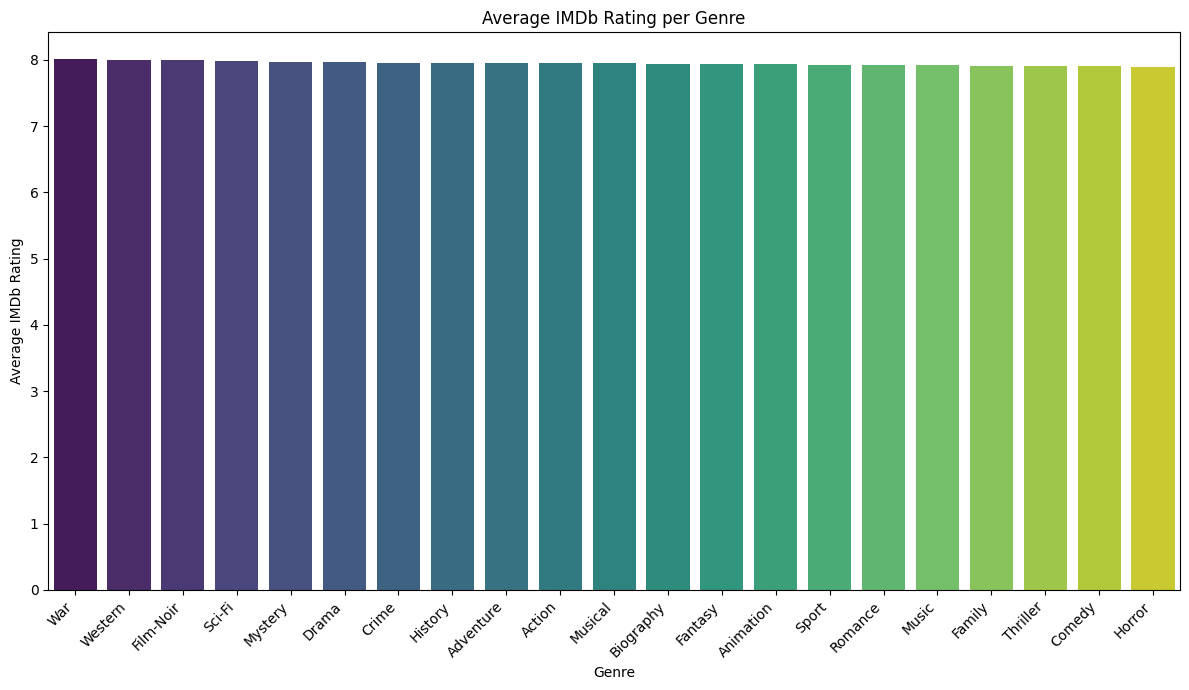

Average rating for Drama genre: 7.959392265193371
Overall average IMDb rating: 7.949299999999999


In [8]:
# Data preparation for Hypothesis 1
genres_df = df.assign(Genre=df['Genre'].str.split(', ')).explode('Genre')
avg_rating_per_genre = genres_df.groupby('Genre')['IMDB_Rating'].mean().sort_values(ascending=False)

# Visualization for Hypothesis 1
plt.figure(figsize=(12, 7))
sns.barplot(x=avg_rating_per_genre.index, y=avg_rating_per_genre.values, palette='viridis')
plt.title('Average IMDb Rating per Genre')
plt.xlabel('Genre')
plt.ylabel('Average IMDb Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Average rating for Drama genre:", avg_rating_per_genre.loc['Drama'])
print("Overall average IMDb rating:", df['IMDB_Rating'].mean())

## Hypothesis 2: There is a positive correlation between the number of votes a movie receives and its IMDb rating.

In [9]:
# Data preparation for Hypothesis 2
df['No_of_Votes'] = df['No_of_Votes'].str.replace(',', '').astype(int)

# Visualization for Hypothesis 2
plt.figure(figsize=(10, 6))
sns.scatterplot(x='No_of_Votes', y='IMDB_Rating', data=df, alpha=0.6)
plt.xscale('log') # Use log scale for better visualization due to wide range of votes
plt.title('IMDb Rating vs. Number of Votes')
plt.xlabel('Number of Votes (Log Scale)')
plt.ylabel('IMDb Rating')
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = df['No_of_Votes'].corr(df['IMDB_Rating'])
print(f"Correlation between Number of Votes and IMDb Rating: {correlation:.2f}")

AttributeError: Can only use .str accessor with string values!

## Hypothesis 3: Movies released in the 1990s have a higher representation in the IMDb Top 1000 list compared to other decades.

In [ ]:
# Data preparation for Hypothesis 3
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')
df['Decade'] = (df['Released_Year'] // 10 * 10).astype(str) + 's'
movies_per_decade = df['Decade'].value_counts().sort_index()

# Visualization for Hypothesis 3
plt.figure(figsize=(12, 7))
sns.barplot(x=movies_per_decade.index, y=movies_per_decade.values, palette='plasma')
plt.title('Number of Top 1000 Movies per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Number of movies in the 1990s:", movies_per_decade.get('1990s', 0))